# Ejercicios Visión Artificial

In [2]:
import cv2               as cv
import matplotlib.pyplot as plt
import numpy             as np
import scipy.signal      as signal
import os


## Ejercicio 1: Calibración

### Apartado a. Calibración precisa

Realiza una calibración de tu cámara mediante múltiples imágenes de un chessboard. Para esto hacemos una serie de imágenes de un tablero de ajedrez que guardamos en la carpeta /images/cali.
A continuación, modificamos el código de "calibrate.py" que vimos en las prácticas para que busque las esquinas de un tablero 8x8 (en lugar de 10x7).
Para realizar la calibración precisa, simplemente llamamos a "calibrate.py"

In [3]:
os.system("./Obligatorios/01-calibrate.py \"./images/cali/cali[1-7].jpg\"")

processing ./images/cali/cali2.jpg...
ok
processing ./images/cali/cali5.jpg...
ok
processing ./images/cali/cali3.jpg...
ok
processing ./images/cali/cali7.jpg...
ok
processing ./images/cali/cali1.jpg...
ok
processing ./images/cali/cali4.jpg...
ok
processing ./images/cali/cali6.jpg...
ok
RMS: 0.6865890305218385
camera matrix:
 [[1.99257809e+03 0.00000000e+00 9.91624208e+02]
 [0.00000000e+00 2.00243942e+03 1.06676409e+03]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]]
distortion coefficients:  [ 0.18494318 -1.59497813  0.00571314 -0.00524928  5.07626368]


0

Recordemos que este este programa devuelve una mátriz: $$K =\begin{bmatrix}f & s & o_x \\  0 & fr & o_y \\ 0 & 0 & 1\end{bmatrix}$$ 

De acuerdo a esto, tenemos que el FOV es 2000 tanto vertical como horizontalmente.

### Apartado b. Calibración aproximada

Volvemos a usar el tablero de ajedrez. En /images/cali, encontramos la imagen "caliAprox.jpg" que ha sido tomada a una altura de 1 metro. Al medir los bordes del tablero obtenemos que miden 40 cm.

Puede comprobarse que las esquinas del tablero se encuentran en los pixeles indicados a continuación. A partir de estas medidas podemos calcular las medidas aproximadas de los bordes.

Esquinas del tablero (599,698),(1421,703),(1421,1515),(603,1525)
Medidas bordes: 822 pix, 812 pix, 818 pix, 827 pix (Empezando arriba en sentido contrario a agujas del reloj)
Tamaño imagen: 2048x2048
u,v se calculan haciendo la media de los bordes

Además, sabemos que el tablero mide 40 cm en cada dirección y la imagen se ha tomado de aproximadamente 1 metro de altura. El programa que tenemos a continuación calcula el FOV a partir de estos datos.

In [13]:
import numpy as np
w,h = 2048,2048
X,Y = 0.4,0.4
u,v = 820,820
Z = 1.0
fh = u / (X/Z)
fv = v / (Y/Z)
FOVh = 2*np.rad2deg(np.arctan((w/2)/fh))
FOVv = 2*np.rad2deg(np.arctan((h/2)/fv))
print('FOV horizontal: ' + str(FOVh), 'FOV vertical: ' + str(FOVv))

FOV horizontal: 53.08537497195191 FOV vertical: 53.08537497195191


Observamos que el valor aproximado de f es 2500, mientras que el valor preciso es 2000. Como 2500/2000 = 1.25 < 1.3, podemos concluir que la calibración es decente.

### Apartado c. Altura para que la cámara abarque un campo de baloncesto

Observemos que para que el campo de baloncesto se encuentra en la imagen tiene que cumplirse (usando la notación del código anterior):
    - w > u = f * (X/Z)
    - h > v = f * (Y/Z)
Sabiendo que f = 2000 (aproximando el resultado obtenido en calibración precisa), que (X,Y) = (28,15) (dimensiones de un campo de baloncesto en metros) y que (w,h) = (2048,2048) (resolución de la cámara):
    - Z > 2000 * (28 / 2048)
    - Z > 2000 * (15 / 2048)
De donde obtenemos, Z > 27.34. Tendremos que poner la cámara a 27.34 metros de altura como mínimo.

En general, si un objeto tiene dimensiones (X,Y) y queremos que esté completamente dentro de la imagen y que la cámara esté paralela al objeto. Tendremos que poner la cámara  más de (2000/2048)*max(X,Y)~max(X,Y) unidades de distancia.

### Apartado d. Ángulo entre 2 puntos

TODO

## Ejercicio 2: Actividad

Construye un detector de movimiento en una región de interés. Guarda 2 o 3 segundos de la secuencia. Muestra el objeto seleccionado anulando el fondo.

En primer lugar, expliquemos como se ha resuelto el ejercicio. En primer lugar, el usuario selecciona una región mediante un ROI, donde se llevará a cabo el análisis.

El problema se resume en crear un modelo que usaremos para implementar un detector de movimiento. Este modelo puede crearse de muchas formas, una de las primeras que se utilizó en la resolución de este ejercicio consistía en calcular la varianza de cada pixel en los últimos frames (implementado guardando una deque de los últimos frames y llamando a np.var) o calcular la media y comparar con el frame actual.
Sin embargo, al final nos hemos quedado con un modelo de aprendizaje sencillo que construye el modelo actual a partir del modelo anterior y la imagen actual mediante la fórmula: $$modelo = (1 - learning_rate) * modelo + learning_rate * frame$$ dado un learning_rate entre 0 y 1. Dado este modelo podemos calcular la diferencia entre el frame actual y el modelo (valor absoluto). A partir de este mapa de distancia podemos utilizar diferentes criterios para crear la imagen que detecta objetos en movimiento. Podríamos simplemente utilizar la imagen diferencia reescalada entre 0 y 1, o convertir el mapa a un mapa de probabilidad. Sin embargo el criterio utilizado, utiliza Thresholding adaptativo para detectar donde se encuentran los objetos (aplica Thresholding a la imagen distancia para obtener una máscara).
La utilización de backgroundSubstraction es bastante similar a como se aprendió en clase.

Por último, un pequeño manual de uso:
- 'x' : Reinicia el programa
- 'b' : Cambia el modelo de background substraction (por defeecto) al propio
- 'u' : Si nuestro modelo debe aprender a partir de los frames actuales (por defecto sí). Si la cámara permanece estática y podemos grabar el fondo antes de que entren los objetos puede ser inteligente usar esta opción.
- 'v' : Inicia o para grabación
- 'r' : Libera el video

Nota: La función video.write() dió problemas a la hora de leer el video después. Los reproductores esperan el video en un formato con 3 canales y estaba guardando el video en blanco y negro (1 canal). Debido a esto, antes de guardar la imagen en el video la pasamos a formato BGR.


In [11]:
os.system("./Obligatorios/02-actividad.py --dev=http://192.168.100.203:8080/video")

1920x1080 25.0fps
video: recording
recording MJPG video 20240115-202444.avi with resolution 799x410 at 15fps


[mjpeg @ 0x2db9dc0] overread 8


video: paused
20 frames written to video


0

## Ejercicio 3: Color

Construye un contador de objetos que tengan un color característico en la escena, simplemente pinchando con el ratón en dos o tres de ellos.

Se proporcionan 2 métodos para resolver el ejercicio.
En el primer método usamos la función inRange. Para hacerlo debemos indicar el rango de colores que pensamos que tiene nuestro objeto.
Para encontrar este rango, calculamos el valor medio y la desviación típica de los puntos. El rango será $$[mean - sigma * var, mean + sigma * var]$$ para un cierto sigma. Una vez tenemos la función inRange buscamos los contornos de dicha imagen y nos quedamos con aquellos bordes lo suficientemente grande para que consideremos que existe un objeto dentro. Construimos una máscara rellenando los bordes y devuelve el número de bordes encontrados (igual al número de objetos en la imagen de dicho color).

En el segundo método usamos la distribución de probabilidad gaussiana con media y desviación típica igual al conjunto de colores. Esta función de probabilidad aplicada a cada pixel convierte la imagen convierte la imagen en una imagen con valores entre 0 y 1 en 3 canales (que son colapsados mediante la función mínimo). Esta imagen podría binarizarse y hacer lo mismo que hemos hecho en el método anterior para conseguir el número de objetos, pero con este método solamente estaba intentando construir la imagen de probabilidad.

Manual de uso:
- 'x' : Reinicia el programa
- 's' : Inicia el proceso de selección de colores
- 'c' : Empieza el programa propiamente dicho
Para utilizar el programa tras lanzarlo se debe pulsar 's' para entrar en el estado de selección de colores. A continuación, seleccionamos al menos 2 puntos en la imagen de los cuales se guarda el color (pueden ser más, conforme más seleccionemos mejor se reconocerán los objetos). A continuación, presionamos 'c' para empezar el programa.

In [ ]:
os.system("./Obligatorios/03-color.py --dev=http://192.168.100.203:8080/video")

## Ejercicio 4: Filtros

Amplía el código de la práctica 4 para mostrar en vivo el efecto de diferentes filtros, seleccionando con el teclado el filtro deseado y modificando sus parámetros (p.ej. el nivel de suavizado) con trackbars. Aplica el filtro en un ROI para comparar el resultado con el resto de la imagen (ejemplo).

Para este ejercicio se ha desarrollado un programa que nos permite ejecutar cualquiera de los filtros vistos en clase.
En primer lugar, se selecciona un área de la imagen que será el área a modificar con el filtro. A continuación, podemos aplicar cualquier filtro a dicho área pulsando las siguientes teclas:
- '0' : Ningun filtro.
- '1' : Filtro de convolución. La máscara de convolución será una matriz 3x3. Podemos seleccionar sus índices.
- '2' : Filtro de caja. Es similar a un filtro de convolucion con índices iguales y normalizados (suman 1). Podemos seleccionar el tamaño de la máscara tanto en dirección vertical como horizontal.
- '3' : Filtro gaussiano. Puede seleccionarse el valor de sigma. El tamaño de la máscara se calcula automáticamente mediante el valor de sigma.
- '4' : Filtro de mediana. Podemos seleccionar el tamaño de la máscara.
- '5' : Filtro bilateral. Podemos seleccionar el tamaño de la caja en la que promediamos los pixeles y valores sigma en el espacio de colores y en el espacio (conforme más grande sean mezaclaremos pixeles más lejanos en el espacio de colores y en la imagen).
- '6' : Filtro del mínimo. Podemos seleccionar el tamaño de la máscara.
- '7' : Filtro del máximo. Podemos seleccionar el tamaño de la máscara.

El programa es largo y pesado de leer, pero la idea es muy sencilla. Al pulsar la tecla adecuada se crea una ventana específica para dicho filtro que contiene los trackbars necesarios para seleccionar los parámetros del filtro. Dependiendo del filtro activo actualmente, recuperamos los valores de los trackbar y aplicamos el filtro a frame[y1:y2+1,x1:x2+1] (la región del ROI). Además, presionando la tecla 'x' se reinicia el programa y con la tecla 'c' cambiamos entre la imagen en blanco y negro, y la imagen en color.

In [ ]:
os.system("./Obligatorios/04-filtros.py --dev=http://192.168.100.203:8080/video")

### Comprueba la propiedad de "cascading" del filtro gaussiano.

La propiedad de "cascading" nos dice que si aplicamos dos filtros gaussianos de forma consecutiva. El resultado será equivalente al de aplicar un cierto filto gaussiano. En particular el valor de sigma al cuadrado de este filtro será igual a la suma de los valores de sigma al cuadrado de los otros dos filtros. Para comprobar esta propiedad, aplicamos dos filtros gaussianos consecutivamente. Por otro lado, aplicamos un filtro gaussiano con el valor de sigma adecuado y comparamos los resultados, dejamos que el tamaño del filtro se elija automáticamente. En particular, para los valores de sigma utilizamos la terna pitagórica (25^2 = 20^2 + 15^2).

In [18]:
def readrgb(file):
    return cv.cvtColor( cv.imread("./images/"+file), cv.COLOR_BGR2RGB) 

def rgb2gray(x):
    return cv.cvtColor(x,cv.COLOR_RGB2GRAY)

def gray2float(x):
    return x.astype(float) / 255

def imshowg(x):
    plt.imshow(x, 'gray')

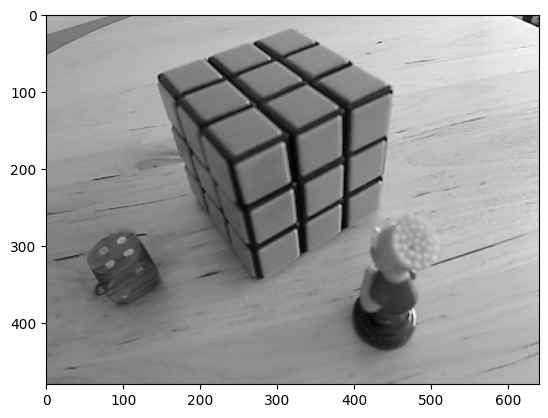

In [19]:
auto = (0,0)
sigma1 = 15
sigma2 = 20
sigma3 = 25
imagen = readrgb("cube3.png")
g = rgb2gray(imagen)
f = gray2float(g)
imshowg(f)

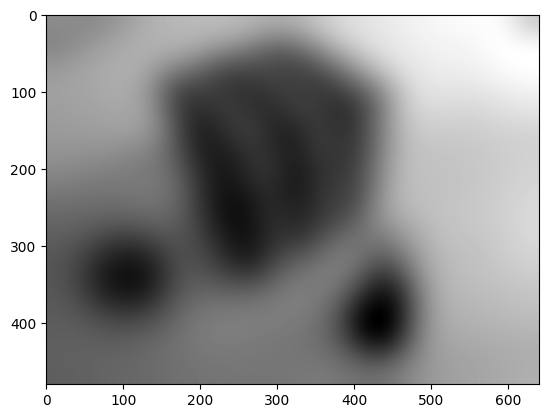

In [26]:
resultado = cv.GaussianBlur(f, auto, sigma1)
resultado = cv.GaussianBlur(resultado, auto, sigma2)
imshowg(resultado)

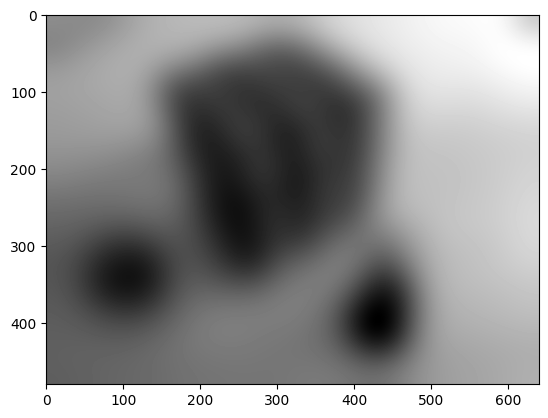

In [27]:
resultado2 = cv.GaussianBlur(f, auto, sigma3)
imshowg(resultado2)

In [28]:
np.max(np.abs(resultado - resultado2))

2.2791089736240444e-05

Resulta evidente que el resultado es el mismo cuando aplicamos los 2 métodos.

### Comprueba la propiedad de "separabilidad" del filtro gaussiano.

La propiedad de "separabilidad" nos dice que la aplicación de un filtro gaussiano en 2 dimensiones es equivalente a aplicar 2 filtros gaussianos en 1 dimensión. Un filtro gaussiano en 2 dimensiones puede separarse en filtros gaussianos en cada una de las dimensiones. Partimos de la imagen anterior, ya transformada a punto flotante. Entonces aplicamos filtros Gaussianos en la coordenada horizontal y vertical, y mostramos la imagen. A continuación aplicamos un filtro gaussiano bidimensional, mostramos la imagen y comparamos los resultados. Ahora, trabajamos con la dimensión de la máscara, dejando que el valor de sigma se elija automáticamente.

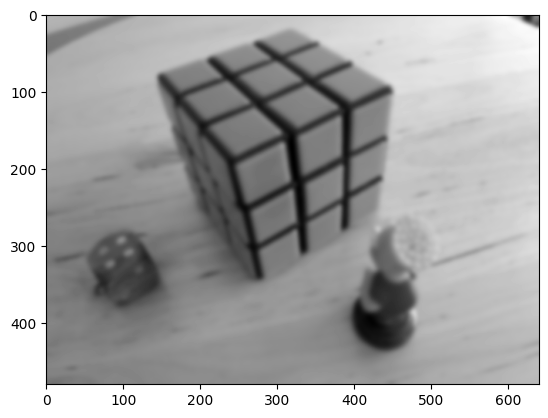

In [34]:
resultado = cv.GaussianBlur(f,(1,17),0)
resultado = cv.GaussianBlur(resultado,(17,1),0)
imshowg(resultado)

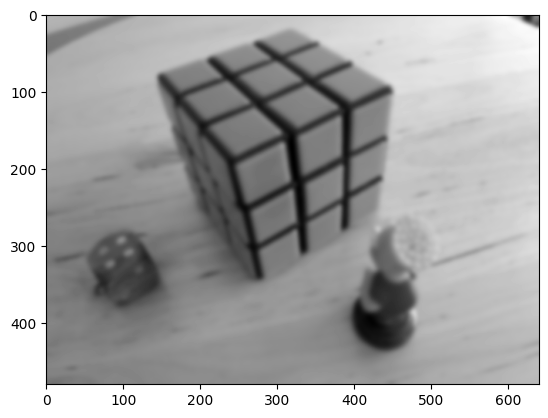

In [35]:
resultado2 = cv.GaussianBlur(f,(17,17),0)
imshowg(resultado2)


In [36]:
np.max(np.abs(resultado - resultado2))

5.551115123125783e-16

Otra vez volvemos a obtener los mismo resultados en ambos métodos.

### Implementa el algoritmo de convolución con una máscara general

La función para calcular la convolución recibe como parámetro una matriz de convolución con tamaño impar en ambas dimensiones. Aplicamos la convolución dependiendo del escenario en el que nos encontremos, otra opción que se consideró y que es equivalente es crear una imagen con 0s alrededor y aplicar simplemente el primer escenario. El reajuste por los bordes podría perfectamente no aplicarse ya que no afectará significativamente a la imagen global mientras el kernel no sea muy grande.

In [98]:
def convolucion(k,x):
    m,n = k.shape
    assert n%2==1 and m%2 == 1
    n2 = int((n-1)/2)
    m2 = int((m-1)/2)
    r,s=x.shape
    assert m < r and n < s
    convolucion = np.zeros((r,s))
    for i in range(m2,r-m2-1):
        for j in range(n2,s-n2-1):
            convolucion[i,j] = np.sum(np.multiply(x[i-m2:i+m2+1,j-n2:j+n2+1],k)) / ((2*m2+1)*(2*n2+1))
        for j in range(n2):
            convolucion[i,j] = np.sum(np.multiply(x[i-m2:i+m2+1,0:j+n2+1],k[:,n2-j:])) / ((2*m2+1)*(j+n2+1))
        for j in range(s-n2-1,s):
            convolucion[i,j] = np.sum(np.multiply(x[i-m2:i+m2+1,j-n2:s],k[:,:s-j+n2])) / ((2*m2+1)*(s+n2-j))
    for i in range(m2):
        for j in range(n2):
            convolucion[i,j] = np.sum(np.multiply(x[0:i+m2+1,0:j+n2+1],k[m2-i:,n2-j:])) / ((i+m2+1)*(j+n2+1))
        for j in range(n2,s-n2-1):
            convolucion[i,j] = np.sum(np.multiply(x[0:i+m2+1,j-n2:j+n2+1],k[m2-i:,:])) / ((i+m2+1)*(2*n2+1))
        for j in range(s-n2-1,s):
            convolucion[i,j] = np.sum(np.multiply(x[0:i+m2+1,j-n2:s],k[m2-i:,:s-j+n2])) / ((i+m2+1)*(s+n2-j))
    for i in range(r-m2-1,r):
        for j in range(n2):
            convolucion[i,j] = np.sum(np.multiply(x[i-m2:r,0:j+n2+1],k[:r-i+m2,n2-j:])) / ((r-i+m2)*(j+n2+1))
        for j in range(n2,s-n2-1):
            convolucion[i,j] = np.sum(np.multiply(x[i-m2:r,j-n2:j+n2+1],k[:r-i+m2,:])) / ((r-i+m2)*(2*n2+1))
        for j in range(s-n2-1,s):
            convolucion[i,j] = np.sum(np.multiply(x[i-m2:r,j-n2:s],k[:r-i+m2,:s-j+n2])) / ((r-i+m2)*(s+n2-j))
    return convolucion  * ((2*m2+1)*(2*n2+1))

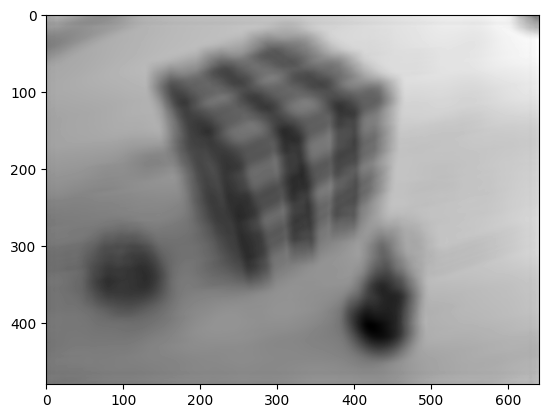

In [99]:
# kernel = np.array([[2,5,4],[-5,1,-5],[0,-2,1]])
kernel = np.random.rand(35,33)
kernel = kernel / np.sum(kernel) *2
myConvolucion= convolucion(kernel,f)
imshowg(myConvolucion)

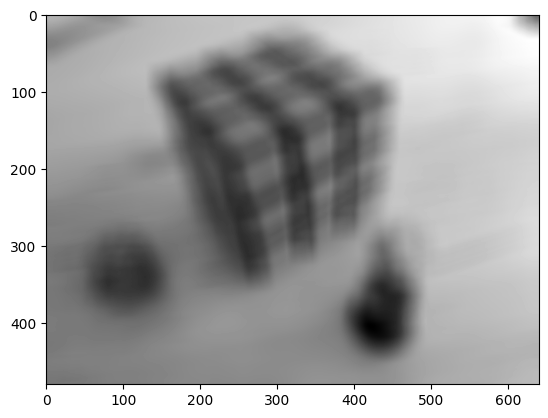

In [100]:
cvConvolucion = cv.filter2D(f,-1, kernel)
imshowg(cvConvolucion)

0.0013580413813010098
0.14510648717779917
0.5540221354166667 1.107810602220207 1.1080732470994243


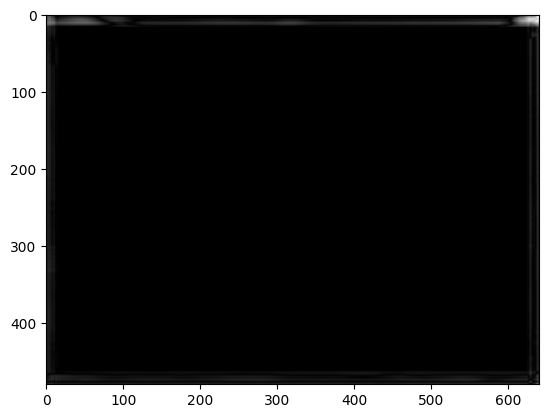

In [101]:
print(np.mean(np.abs(myConvolucion - cvConvolucion)))
print(np.max(np.abs(myConvolucion - cvConvolucion)))
print(np.mean(f),np.mean(myConvolucion),np.mean(cvConvolucion))
imshowg(np.abs(cvConvolucion-myConvolucion))

Como puede verse los métodos de cv y el implementado dan aproximadamente el mismo resultado, sin embargo, el error máximo sí es bastante significativo. Esto puede deberse a una diferencia de criterio al implementar el método en los bordes. De hecho en la imagen error podemos observar qie efectivamente falla en los bordes.

### Implementa el box filter con la imagen integral

En primer lugar, para crear la imagen integral sumamos a cada índice de la matriz todos los elementos que se encuentren a su izquierda y encima (en toda la submatriz que se encuentra encima a su izquierda). Nótese que puede hacerse de forma eficiente sumando de la siguiente forma: 
- I(x,y) = i(x,y) + I(x-1,y) + I(x,y-1) - I(x-1,y-1), donde I representa la matriz integral e i representa la matriz original.

La matriz integral tiene la propiedad de que la suma del bloque (a1:b1,a2:b2) de la matriz original es I(a2,b2) - I(a1,b2) - I(a2,b1) + I(a1,b1). Por lo tanto para calcular el boxFilter de tamaño (n,m) una vez tenemos la imagen integral simplemente tenemos que llevar a cabo la operación: box(i,j) = I(i-m2,j-n2) - I(i+m2+1,j+n2) - I(i-m2,j+n2+1) + I(i+m2+1,j+n2+1) (se vuelve a complicar en los bordes)

In [124]:
def box_filter(x, m, n):
    r,s = x.shape
    assert m%2==1 and n%2==1
    m2 = int((m-1)/2)
    n2 = int((n-1)/2)
    producto = m * n
    integral = np.zeros((r+1,s+1))  # Añadimos una columna y una fila de 0s para no distinguir casos especiales en los bordes
    for i in range(r):
        for j in range(s):
            integral[i+1,j+1] = x[i,j] + integral[i+1,j] + integral[i,j+1] - integral[i,j]
    box = np.zeros((r,s))
    # Interior de la imagen
    for i in range(m2,r-m2):
        for j in range(n2,s-n2):
            box[i,j] = integral[i-m2,j-n2] - integral[i-m2,j+n2+1] \
                    - integral[i+m2+1,j-n2] + integral[i+m2+1,j+n2+1]
        for j in range(n2):
            box[i,j] = integral[i+m2+1,j+n2+1] - integral[i-m2,j+n2+1]
        for j in range(s-n2,s):
            box[i,j] = integral[i-m2,j-n2] - integral[i-m2,s] \
                    - integral[i+m2+1,j-n2] + integral[i+m2+1,s]
    for i in range(m2):
        for j in range(n2):
            box[i,j] = integral[i+m2+1,j+n2+1]
        for j in range(n2,s-n2):
            box[i,j] = - integral[i+m2+1,j-n2] + integral[i+m2+1,j+n2+1]
        for j in range(s-m2,s):
            box[i,j] = - integral[i+m2+1,j-n2] + integral[i+m2+1,s]
    for i in range(r-m2,r):
        for j in range(n2,s-n2):
            box[i,j] = integral[i-m2,j-n2] - integral[i-m2,j+n2+1] \
                    - integral[r,j-n2] + integral[r,j+n2+1]
        for j in range(n2):
            box[i,j] = integral[r,j+n2+1] - integral[i-m2,j+n2+1]
        for j in range(s-m2,s):
            box[i,j] = integral[i-m2,j-n2] - integral[i-m2,s] \
                    - integral[r,j-n2] + integral[r,s]
    # Dividemos la imagen por producto para normalizarla
    # En los bordes podríamos dividirla por menos pues hay menos sumandos, pero se ha
    # decidido ignorar este problema para mantener simplicidad
    return box / producto

In [128]:
cvBox = cv.boxFilter(f,-1,(5,3))
myBox = box_filter(f,3,5)
print(np.mean(np.abs(cvBox-myBox)),np.mean(cvBox),np.mean(myBox))
print(np.max(np.abs(cvBox - myBox)))

0.0020594532966129978 0.554023247719227 0.5519637944238361
0.6588235294117657


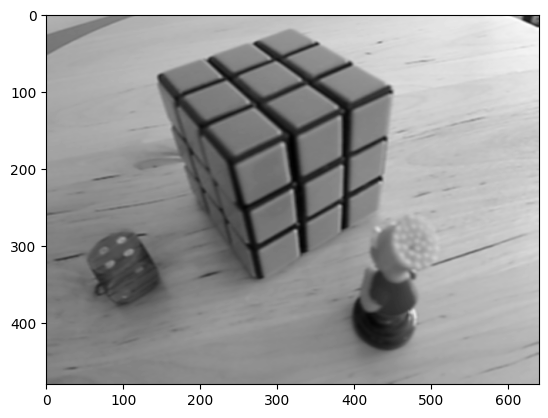

In [129]:
imshowg(cvBox)

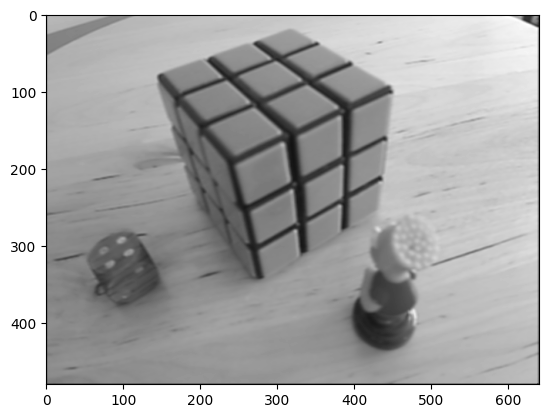

In [130]:
imshowg(myBox)

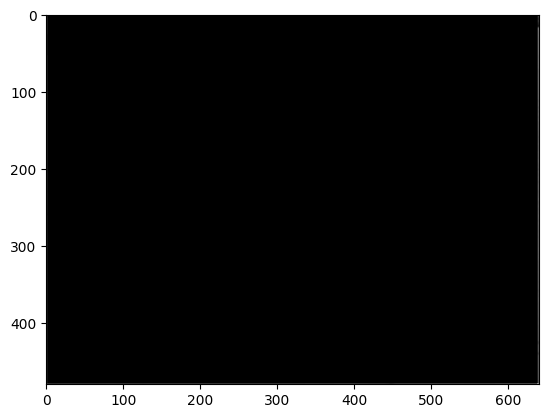

In [131]:
imshowg(np.abs(myBox - cvBox))

Observamos que conseguimos el mismo resultado al aplicar el método de OpenCV y el implementado manualmente. Simplemente hay que recordar introducir las dimensiones del filtro en orden contrario, que me ha llevado un tiempo darme cuenta de esto, pensando que era un error de código.

### Añade la posibilidad de aplicar varios filtros
No se ha realizado este apartado.

## Ejercicio 5: SIFT

Escribe una aplicación de reconocimiento de objetos basada en el número de coincidencias de "keypoints".

Supongamos que tenemos un codebook como se indica en bag-of-words.ipynb, etonces construimos para cada imagen el histograma de a que cluster pertenece cada keypoints. En nuestra región de interés calculamos el mismo histograma y lo comparamos con los modelos. En una esquina se muestra el modelo más parecido. Presionando 's' guardamos el ROI actual como uno de los modelos y recalculamos su histograma. Presionando 'u' recalculamos el codebook. También podemos eliminar los ficheros para que se vuelvan a calcular al arrancar el programa.

In [ ]:
os.system('./05-sift.py --dev=http://172.22.70.115:8080/video')

## Ejercicio 6: RECTIF

En este ejercicio medimos distancias gracias a unos puntos de referencia. En primer lugar, presionamos 'r' y seleccionamos los puntos de referencia (esquinas de un DNI) y a continuación presionamos 'p' y seleccionamos los puntos cuya distancia queremos medir (en el mismo plano que los puntos de referencia). Al presionar 'c' se medirá dicha distancia.

In [ ]:
os.system('./06-rectif.py --dev=http://172.22.70.115:8080/video')

Los puntos de referencia hay que introducirlos empezando por la esquina superior izquierda, después la inferior izquierda, inferior derecha y superior derecha. Como ejemplo, tenemos la siguiente imagen, relativamente cercana a la realidad.
A continuación se proporciona un ejemplo de ejecución del programa en el que podemos observar que la distancia calculada es similar a la distancia en el mundo real.

![Ejemplo](./images/RECTIF.png)

## Ejercicio 7: RA
Crear un efecto de realidad aumentada. En particular, el cubo sigue al ratón (más o menos).

Me habría gustado hacer algo más impresionante pero al final, no me da tiempo de entregar algo mejor. El programa se basa en el que vimos en clase de prácticas (pose2.py). Básicamente se ha añadido un listener a la ventana que permite que se guarde la posición donde hacemos click con el ratón. Usamos esta posición para mover el cubo, sin embargo, no es tan sencillo pues las coordenadas del ratón están en las coordenadas de la imagen mientras que el cubo está en las coordenadas de la cámara (3-dimensionales). Para resolver esto, aplicamos htrans a las posiciones del cubo para convertirlas a coordenada de la imagen. Y movemos el cubo en la dirección que apunte la resta: ((xRealCube-xMouse)/frame.shape[1],(yRealCube-yMouse)/frame.shape[0]).
Ahora bien, no se me ha ocurride ninguna forma de convertir de esa resta a las coordenadas del espacio. Por eso simplemente se multiplica la resta por un escalar, algo que funciona sorprendentemente bien, y se incrementa la posición en el espacio 3-dimensional de acuerdo a esta multiplicación.

El programa solo está preparado para ejecutarse con la entrada "marker.png". Si se ejecuta con cualquier otro fichero dará error.

In [54]:
os.system("./Obligatorios/07-ra.py --dev=dir:./images/marker.png")

0

## Opcional 1: DELOGO

La idea básica de este ejercicio es clara. Los logos de una transmisión son las partes estáticas, por lo que comparando un frame con el anterior podemos ver que partes se han quedado igual. Después en una máscara que marca las partes estáticas, vamos eliminando las partes que han cambiado. Por último, llamamos a inpaint sobre la máscara de partes estáticas. 
En la práctica no resulta tan sencillo, por algún motivo los pixeles del logo también cambian, lo que complica bastante el programa. Se pensó en utilizar otros métodos, como contar cuantas veces habían cambiado en los últimos frames antes de aceptar sacar a un pixel de la máscara estática, pero no dieron buen resultado, por lo que mantenemos el programa sencillo.
Presionando la tecla 'x', se reinicia la máscara estática.

In [ ]:
os.system("./Opcionales/01-delogo.py")

## Opcional 2: SILU
En este ejercicios queremos utilizar el reconocedor de siluetas para reconocer matrículas de coche. Seguimos la misma idea que en las prácticas, calculamos los contornos de nuestra imagen y para aquellos suficientemente buenos calculamos su invariante. Comparando los invariantes de las siluetas de nuestro modelo con los invariantes de las siluetas de nuestra imagen podemos saber si nuestra imagen contiene alguna letra o número.
Respecto a creiterios a justificar, se ha utilizado la distancia al mejor (menor que 0.1 (valor arbitrario)) como discriminante para decidir si 2 siluestas son suficientemente parecidas, pero también podríamos haber comparado la diferencia entre la distancia al mejor y la distancia al segundo mejor, podría dar problemas con 6 y 9. Se ha decidido excluir la letra 'I' debido a que las líneas eran marcadas como Ies. Se puede probar a quitar esta restricción y se verá como hay muchos falsos positivos. 

Al ejecutar el programa aparecen distintas imagenes. En primer lugar se muestra nuestro modelo y a continuación, las tranformaciones que se le hacen para facilitar la búsqueda de los bordes. Después aparece la imagen que estamos utilizando, con los bordes que se han detectado como letras o números marcados en rojo. Por último, aparece la imagen que hemos utilizado para sacar los bordes (está última imagen se muestra para comprobar que la imagen no se esté deformando excesivamente en las transformaciones previas a extraer los bordes).

NOTA: El programa está listo para ser ejecutado desde aquí. Sí se ejecuta desde la carpeta Opcionales hay que cambiar el código, añadiendo un punto a las direcciones de las imagenes ('./images' -> '../images')

In [12]:
os.system("./Opcionales/02-silu.py")

0.09960493042801857 8
0.07415280641260838 5
0.012394955559494717 8
0.021418783465256476 6
0.0641893191020426 5
0.02530703641847858 L
0.057374846423244766 C
['8', '5', '8', '6', '5', 'L', 'C']


0

Se consiguen resultados decentes, pero no perfectos. No se detecta la 'V' en la matrícula y la franja azul se detecta como una '8' aunque podría descartarse si restringiesemos el valor de 0.1.
También podemos observar que el 9 se detecta como un 6, aunque es un error comprensible dado su parecido.

## Opcional 3: CR
Para llevar a cabo este ejercicio, se ha utilizado el cross-ratio de 4 puntos para calcular puntos equidistantes. También se nos pide que calculemos el punto de fuga, para lo que hemos demostrado que si la distancia entre el punto 1 y el punto 0 (distancia a) es mayor que la distancia entre el punto 2 y el punto 1 (distancia b), es decir los puntos se alejan de la cámara podemos encontrar el punto de fuga a una distancia del punto 2 igual a b*(b+a)/(a-b).
Esto es una demostración matemática, si me acuerdo, adjuntaré una foto de la demostración pues no la tengo a mano ahora mismo. 

Manual de uso: Presiona 3 puntos equidistantes en un mismo plano, a continuación presiona la tecla 'c'. Se recomienda usar los raíles como referencia.

In [1]:
os.system('./Opcionales/03-cr.py')

NameError: name 'os' is not defined

Se muestra a continuación un ejemplo de ejecución del programa.

![Ejemplo](./images/CR/resultado.png)

Como puede verse, se consiguen muy buenos resultados, demostrando que la demostración es correcta. Dicho eso, el programa es muy sensible a donde se encuentran los puntos, lo que hace que si no se presionan como mucho cuidado pueda dar resultados erróneos.

## Opcional 4: SWAP
En este programa tenemos que cambiar 2 rectángulos de posición. Esto se hace utilizando homografías. Una vez tenemos los cuadriláteros seleccionados calculamos las homografías para transformar cada uno en el otro. La imagen objetivo se conseguirá copiando en el interior de estos cuadriláteros el resultado de aplicar la homografía a la imagen (es decir, copiamos en cada cuadrilátero el otro).

Originalmente se iba a hacer uso de un cuadrado ideal que actuase de intermediaro, pero se vió que no hacía falta y tampoco facilitaba la programación, por lo que se descartó la idea.

Manual de uso: Presionar la tecla '1' para comenzar a rellenar el cuadrilátero 1 y seleccionar las 4 esquinas. Presionar la tecla '2' para comenzar a rellenar el cuadrilátero 2 y seleccionar 4 esquinas. Presionar la tecla 'c' para comenzar el programa y realizar el intercambio de cuadriláteros.

In [22]:
os.system("./Opcionales/04-swap.py --dev=http://172.22.70.115:8080/video")

1920x1080 25.0fps


[mjpeg @ 0x1bf1f80] overread 8


0

A continuación se muestra una prueba.

![original](./images/swap/Original.png)

![SWAP](./images/swap/SWAP.png)

Puede observarse que se consiguen buenos resultados.

## Opcional 5: PANO

En este ejercicio se lleva a cabo un proceso de stitching (juntar fotos que se solapan). Para ello, se buscan los puntos clave de cada foto y se comparan entre ellos. Si 2 fotos tienen suficientes puntos clave, las unimos mediante una homografía que lleve los puntos clave de una a los de la otra.

In [4]:
os.system("./Opcionales/05-pano.py")

(24, 1)


usage: stitcher.py [-h] [--mode {0,1}] [--output OUTPUT] img
stitcher.py: error: unrecognized arguments: ./images/pano/pano001.jpg ./images/pano/pano002.jpg ./images/pano/pano003.jpg


512

In [9]:
os.system("./stitcher.py \'./images/pano/*.jpg\' --output=campus.jpg")

./images/pano/pano003.jpg
./images/pano/pano002.jpg
./images/pano/pano001.jpg
./images/pano/pano000.jpg
stitching completed successfully. campus.jpg saved!


0


![Resultado](./campus.jpg)

Como puede observarse sí que consigue un mejor resultado que nuestro programa (cuyos resultados se muestran a continuación).

![Resultado](./images/pano_jupyter/resultado1.png)

![Resultado](./images/pano_jupyter/resultado3.png)

Como puede observarse en la primera imagen se consiguen buenos resultados, sin embargo, al añadir la última imagen (pano004), no se detectan suficientes puntos (y algunos de ellos son muy malos, como se muestra en la segunda imagen). Si se comenta la segunda parte del programa y se mete la imagen en la carpeta 'pano', puede verse que se consigue esta imagen.

![Error](./images/pano_jupyter/error.png)

## Opcional 6: Sudoku

Desgraciadamente, no he conseguido resolver este ejercicio aunque sea al que más tiempo le he dedicado. Aunque no funcione bien, adjunto el código por si es de interés.


In [59]:
os.system("./Opcionales/06-sudoku.py --dev=http://172.22.70.115:8080/video")

2024-01-17 18:57:30.567994: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-01-17 18:57:30.569416: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2024-01-17 18:57:30.589561: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-01-17 18:57:30.589593: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-01-17 18:57:30.590163: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to

422/422 [==============================] - 5s 12ms/step - loss: 0.3656 - accuracy: 0.8892 - val_loss: 0.0805 - val_accuracy: 0.9792
1920x1080 25.0fps
(1, 2)


Traceback (most recent call last):
  File "/home/nicocolchero/Code/Vision Artificial/ejercicios/Entrega final/./Opcionales/06-sudoku.py", line 226, in <module>
    sudoku = extractSudoku(warped,model)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/nicocolchero/Code/Vision Artificial/ejercicios/Entrega final/./Opcionales/06-sudoku.py", line 97, in extractSudoku
    digit = extract_digit(imgSudoku[i*h9:(i+1)*h9,j*w9:(j+1)*w9])
            ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/nicocolchero/Code/Vision Artificial/ejercicios/Entrega final/./Opcionales/06-sudoku.py", line 76, in extract_digit
    contours , h = cv.findContours(thresh.copy(), cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)[-2:]
                                   ^^^^^^^^^^^
AttributeError: 'tuple' object has no attribute 'copy'


256

## Opcional 7: CARD
Una vez hayamos detectado los bordes (las esquinas) de la tarjeta, como conocemos sus dimensiones podemos calcular una homografía desde una tarjeta ideal a la tarjeta en la imagen. Como además conocemos las dimensiones de la imagen en la tarjeta, podemos aplicar esa homografía a una imagen cualquiera (que reescalaremos para tener el tamaño de nuestra foto ideal). Por último copiamos nuestra foto transformada en la imagen, que caerá exactamente encima de la foto de la tarjeta. El problema por tanto se resume en conocer las esquinas de la imagen. Criterio para reconocer la tarjeta. Es el borde que puede aproimarse con un error pequeño a un cuadrilátero más grande de la imagen.


In [43]:
os.system("./Opcionales/07-card.py --dev=http://172.22.70.115:8080/video")

1920x1080 25.0fps


0

![Resultado CARD](./images/resultado_CARD.png)

Como puede observarse en la imagen sí que conseguimos superponer la imagen encima de nuestra imagen de DNI. Sin embargo, también es cierto que esta superposición depende mucho del fondo (para que detecte de forma correcta el DNI) y de la orientación. El ningún lugar del programa hemos especificado una orientación por lo que dependiendo de desde donde estemos grabando tomará una u otra.
